# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [2]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import scipy.sparse
# pd.set_option("display.float_format", "{:.2f}".format)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

from implicit.als import AlternatingLeastSquares

import matplotlib.pyplot as plt
import seaborn as sns

/home/mle-user/mle_projects/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
interactions = pd.read_parquet("interactions.parquet")


In [4]:
print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 4)


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [4]:
print("TRACKS")
tracks.info()

print("\nCATALOG_NAMES")
catalog_names.info()

print("\nINTERACTIONS")
interactions.info()

TRACKS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB

CATALOG_NAMES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB

INTERACTIONS
<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dt

In [5]:
display(tracks.head())
display(catalog_names.head())
display(interactions.head())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [6]:
print("tracks:")
print(tracks.isna().sum())

print("\ncatalog_names:")
print(catalog_names.isna().sum())

print("\ninteractions:")
print(interactions.isna().sum())

print("Дубликаты track_id:",
      tracks["track_id"].duplicated().sum())

print("Дубликаты (id, type) в catalog_names:",
      catalog_names.duplicated(subset=["id", "type"]).sum())

print("Полностью дублирующиеся события:",
      interactions.duplicated().sum())

tracks:
track_id    0
albums      0
artists     0
genres      0
dtype: int64

catalog_names:
id      0
type    0
name    0
dtype: int64

interactions:
user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64
Дубликаты track_id: 0
Дубликаты (id, type) в catalog_names: 0
Полностью дублирующиеся события: 0


In [5]:
album_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "album", "id"
    ]
)

artist_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "artist", "id"
    ]
)

genre_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "genre", "id"
    ]
)

unknown_albums = tracks["albums"].apply(
    lambda x: any(album_id not in album_ids for album_id in x)
).sum()

unknown_artists = tracks["artists"].apply(
    lambda x: any(artist_id not in artist_ids for artist_id in x)
).sum()

unknown_genres = tracks["genres"].apply(
    lambda x: any(genre_id not in genre_ids for genre_id in x)
).sum()

print("Треков с неизвестными альбомами:", unknown_albums)
print("Треков с неизвестными артистами:", unknown_artists)
print("Треков с неизвестными жанрами:", unknown_genres)

Треков с неизвестными альбомами: 0
Треков с неизвестными артистами: 0
Треков с неизвестными жанрами: 48345


In [7]:
unknown_genre_counts = tracks["genres"].apply(
    lambda genres: sum(
        genre_id not in genre_ids
        for genre_id in genres
    )
)

print("Распределение количества неизвестных жанров:")
print(unknown_genre_counts.value_counts().sort_index())

print(
    "\nТреков, у которых все жанры неизвестны:",
    (
        unknown_genre_counts
        == tracks["genres"].str.len()
    ).sum()
)

print(
    "Максимальное количество неизвестных жанров у одного трека:",
    unknown_genre_counts.max()
)

Распределение количества неизвестных жанров:
genres
0    951655
1     48321
2        24
Name: count, dtype: int64

Треков, у которых все жанры неизвестны: 3694
Максимальное количество неизвестных жанров у одного трека: 2


In [8]:
tracks["genres"] = tracks["genres"].apply(
    lambda genres: [
        genre_id
        for genre_id in genres
        if genre_id in genre_ids
    ]
)

print(
    "Треков без жанров после очистки:",
    (tracks["genres"].str.len() == 0).sum()
)

Треков без жанров после очистки: 3694


In [9]:
tracks["track_id"] = tracks["track_id"].astype("int32")
catalog_names["id"] = catalog_names["id"].astype("int32")

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### Выводы по первичной подготовке данных

Пропущенные значения в таблицах `tracks`, `catalog_names` и `interactions` отсутствуют. Дубликатов `track_id` в таблице треков и дубликатов по паре `(id, type)` в каталоге также нет.

Идентификаторы `track_id` и `catalog_names.id` были приведены к типу `int32`, поскольку он достаточен для хранения всех значений и позволяет экономить память.

Проверка связности каталога показала, что неизвестных идентификаторов альбомов и исполнителей нет. При этом у 48 345 треков встречались неизвестные идентификаторы жанров. Неизвестные `genre_id` были удалены из списков жанров, сами треки при этом сохранялись. После очистки неизвестных жанров нет. У 3 694 треков список жанров оказался пустым, поскольку все исходные жанры этих треков отсутствовали в каталоге.

Основные проблемы первичных данных были выявлены и обработаны, а данные готовы к дальнейшему EDA и подготовке файлов `items.parquet` и `events.parquet`.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [11]:
user_track_counts = (
    interactions.groupby("user_id")
    .size()
    .rename("tracks_count")
)

print(user_track_counts.describe())

count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
Name: tracks_count, dtype: float64


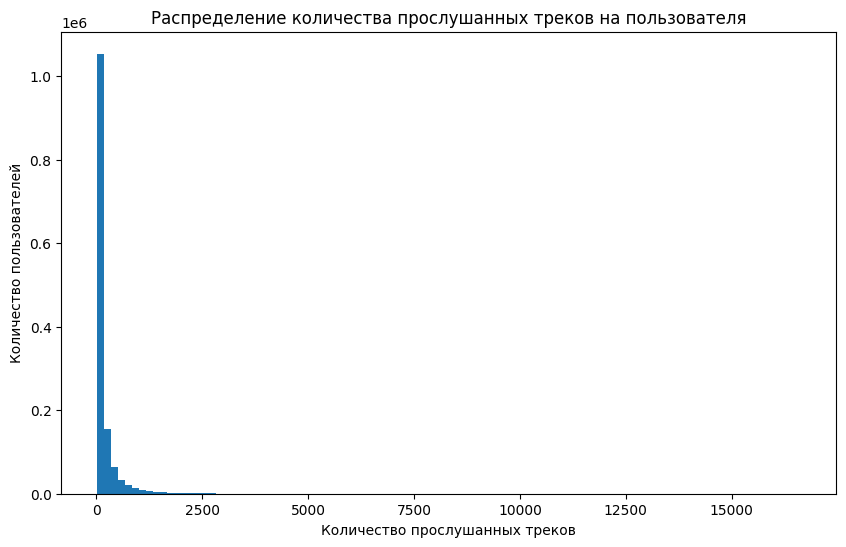

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(
    user_track_counts,
    bins=100
)

plt.xlabel("Количество прослушанных треков")
plt.ylabel("Количество пользователей")
plt.title("Распределение количества прослушанных треков на пользователя")

plt.show()

Наиболее популярные треки

In [12]:
track_popularity = (
    interactions.groupby("track_id")
    .size()
    .rename("listen_count")
    .sort_values(ascending=False)
)

popular_tracks = (
    track_popularity
    .head(20)
    .reset_index()
    .merge(
        catalog_names[catalog_names["type"] == "track"][["id", "name"]],
        left_on="track_id",
        right_on="id",
        how="left"
    )
    .drop(columns="id")
)

display(popular_tracks)

,track_id,listen_count,name
0,53404,111062,Smells Like Teen Spirit
1,33311009,106921,Believer
2,178529,101924,Numb
3,35505245,99490,I Got Love
4,65851540,86670,Юность
5,24692821,86246,Way Down We Go
6,32947997,85886,Shape of You
7,51241318,85244,In The End
8,795836,85042,Shape Of My Heart
9,45499814,84748,Life


Наиболее популярные жанры

In [1]:
track_genres = (
    tracks[["track_id", "genres"]]
    .explode("genres")
    .rename(columns={"genres": "genre_id"})
)

genre_popularity = (
    interactions[["track_id"]]
    .merge(track_genres, on="track_id", how="inner")
    .groupby("genre_id")
    .size()
    .rename("listen_count")
    .sort_values(ascending=False)
)

popular_genres = (
    genre_popularity
    .head(20)
    .reset_index()
    .merge(
        catalog_names[catalog_names["type"] == "genre"][["id", "name"]],
        left_on="genre_id",
        right_on="id",
        how="left"
    )
    .drop(columns="id")
)

display(popular_genres)

NameError: name 'tracks' is not defined

Треки, которые никто не прослушал

In [30]:
listened_track_ids = set(interactions["track_id"].unique())

unlistened_tracks = tracks[
    ~tracks["track_id"].isin(listened_track_ids)
]

print("Количество треков, которые никто не слушал:", len(unlistened_tracks))

Количество треков, которые никто не слушал: 0


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [10]:
items = tracks.copy()

items

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


In [11]:
events = interactions[
    ["user_id", "track_id", "track_seq", "started_at"]
].copy()

events

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


In [12]:
items = items.rename(
    columns={"track_id": "item_id"}
)

events = events.rename(
    columns={"track_id": "item_id"}
)

print(items.columns.tolist())
print(events.columns.tolist())

['item_id', 'albums', 'artists', 'genres']
['user_id', 'item_id', 'track_seq', 'started_at']


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
items.to_parquet("items.parquet", index=False)
events.to_parquet("events.parquet", index=False)

In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

S3_BUCKET_NAME = os.getenv("S3_BUCKET_NAME")
AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")

storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {
        "endpoint_url": "https://storage.yandexcloud.net"
    }
}

In [38]:
items.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/data/items.parquet",
    index=False,
    storage_options=storage_options
)

events.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/data/events.parquet",
    index=False,
    storage_options=storage_options
)

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [14]:
import gc

del tracks
del catalog_names
del interactions

del items
del events

gc.collect()


25

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [15]:
items = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/data/items.parquet",
    storage_options=storage_options
)

events = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/data/events.parquet",
    storage_options=storage_options
)


In [15]:
print("items:", items.shape)
print("events:", events.shape)

items: (1000000, 4)
events: (222629898, 4)


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [16]:
split_date = pd.Timestamp("2022-12-16")

train = events[
    events["started_at"] < split_date
].copy()

test = events[
    events["started_at"] >= split_date
].copy()


In [17]:
print("Train:", train.shape)
print("Test:", test.shape)

print("\nTrain period:")
print(train["started_at"].min(), "—", train["started_at"].max())

print("\nTest period:")
print(test["started_at"].min(), "—", test["started_at"].max())

Train: (208731252, 4)
Test: (13898646, 4)

Train period:
2022-01-01 00:00:00 — 2022-12-15 00:00:00

Test period:
2022-12-16 00:00:00 — 2022-12-31 00:00:00


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Берём последний месяц тренировочной выборки
top_pop_start_date = train["started_at"].max() - pd.Timedelta(days=30)

recent_events = train[
    train["started_at"] >= top_pop_start_date
].copy()

# Чем свежее прослушивание, тем больше его вес
days_ago = (
    train["started_at"].max() - recent_events["started_at"]
).dt.days

recent_events["recency_weight"] = np.exp(-days_ago / 10)

# Считаем популярность трека
item_popularity = (
    recent_events
    .groupby("item_id")
    .agg(
        users=("user_id", "nunique"),
        weighted_listens=("recency_weight", "sum"),
        listens=("item_id", "size")
    )
    .reset_index()
)

# Нормируем признаки
scaler = MinMaxScaler()

item_popularity[
    ["users_norm", "weighted_listens_norm", "listens_norm"]
] = scaler.fit_transform(
    item_popularity[
        ["users", "weighted_listens", "listens"]
    ]
)

# Итоговый score
item_popularity["popularity_score"] = (
    0.4 * item_popularity["users_norm"]
    + 0.4 * item_popularity["weighted_listens_norm"]
    + 0.2 * item_popularity["listens_norm"]
)

# Сортируем по итоговой популярности
item_popularity = item_popularity.sort_values(
    "popularity_score",
    ascending=False
).reset_index(drop=True)

display(item_popularity.head(20))

,item_id,users,weighted_listens,listens,users_norm,weighted_listens_norm,listens_norm,popularity_score
0,83063895,24157,8921.433367,24157,1.000000,1.000000,1.000000,1.000000
1,81848875,23450,8641.636327,23450,0.970732,0.968637,0.970732,0.969894
2,84382282,22731,8579.016372,22731,0.940967,0.961618,0.940967,0.949228
3,60292250,23781,7956.952178,23781,0.984435,0.891891,0.984435,0.947417
4,78426489,22973,8185.924311,22973,0.950985,0.917557,0.950985,0.937614
5,65851540,23408,7907.445474,23408,0.968993,0.886342,0.968993,0.935933
6,75944934,20613,7334.123062,20613,0.853287,0.822078,0.853287,0.840803
7,76434671,20519,7178.095182,20519,0.849396,0.804589,0.849396,0.831473
8,93126179,18349,7393.786297,18349,0.759563,0.828766,0.759563,0.787244
9,51516485,19216,6360.221429,19216,0.795455,0.712913,0.795455,0.762438


In [18]:
catalog_names = pd.read_parquet("catalog_names.parquet")

popular_tracks_view = (
    item_popularity
    .head(20)
    .merge(
        catalog_names[catalog_names["type"] == "track"][
            ["id", "name"]
        ],
        left_on="item_id",
        right_on="id",
        how="left"
    )
    .drop(columns="id")
    .rename(columns={"name": "track_name"})
)

display(
    popular_tracks_view[
        [
            "item_id",
            "track_name",
            "users",
            "weighted_listens",
            "popularity_score"
        ]
    ]
)

,item_id,track_name,users,weighted_listens,popularity_score
0,83063895,Птичка,24157,8921.433367,1.000000
1,81848875,Федерико Феллини,23450,8641.636327,0.969894
2,84382282,Я в моменте,22731,8579.016372,0.949228
3,60292250,Blinding Lights,23781,7956.952178,0.947417
4,78426489,Rampampam,22973,8185.924311,0.937614
5,65851540,Юность,23408,7907.445474,0.935933
6,75944934,Astronaut In The Ocean,20613,7334.123062,0.840803
7,76434671,Горький вкус,20519,7178.095182,0.831473
8,93126179,Солнце Монако,18349,7393.786297,0.787244
9,51516485,bad guy,19216,6360.221429,0.762438


In [19]:
top_popular = (
    item_popularity[
        ["item_id", "popularity_score"]
    ]
    .head(100)
    .copy()
)

top_popular.to_parquet(
    "top_popular.parquet",
    index=False
)


In [20]:
top_popular.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/top_popular.parquet",
    storage_options=storage_options,
    index=False
)

print("top_popular сохранён")

top_popular сохранён


In [21]:
del events
del catalog_names
gc.collect()

72

# Персональные

Рассчитаем персональные рекомендации.

In [22]:
als_start_date = train["started_at"].max() - pd.Timedelta(days=30)

als_train = train[
    train["started_at"] >= als_start_date
].copy()

print("Период ALS:", als_train["started_at"].min(), "—", als_train["started_at"].max())
print("Размер ALS train:", als_train.shape)

Период ALS: 2022-11-15 00:00:00 — 2022-12-15 00:00:00
Размер ALS train: (35561217, 4)


In [23]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

user_encoder.fit(als_train["user_id"])
item_encoder.fit(items["item_id"])

als_train["user_id_enc"] = user_encoder.transform(
    als_train["user_id"]
)

als_train["item_id_enc"] = item_encoder.transform(
    als_train["item_id"]
)

print("Количество пользователей:", len(user_encoder.classes_))
print("Количество треков:", len(item_encoder.classes_))

Количество пользователей: 1069531
Количество треков: 1000000


In [24]:
als_train["weight"] = (
    1 / (als_train["track_seq"] + 1)
)

print(als_train["weight"].describe())

count    3.556122e+07
mean     1.627694e-02
std      4.213339e-02
min      6.267235e-05
25%      1.612903e-03
50%      4.255319e-03
75%      1.265823e-02
max      5.000000e-01
Name: weight, dtype: float64


In [25]:
from scipy import sparse

user_item_matrix = sparse.csr_matrix(
    (
        als_train["weight"].astype(np.float32),
        (
            als_train["user_id_enc"],
            als_train["item_id_enc"]
        )
    ),
    shape=(
        len(user_encoder.classes_),
        len(item_encoder.classes_)
    )
)

print("Размер матрицы:", user_item_matrix.shape)
print("Количество ненулевых элементов:", user_item_matrix.nnz)
print(
    "Плотность матрицы:",
    user_item_matrix.nnz
    / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
)

Размер матрицы: (1069531, 1000000)
Количество ненулевых элементов: 35561217
Плотность матрицы: 3.324935602614604e-05


In [26]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,
    iterations=10,
    regularization=0.05,
    random_state=42
)

als_model.fit(user_item_matrix)

print("ALS-модель обучена")

/home/mle-user/mle_projects/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [01:34<00:00,  9.40s/it]

ALS-модель обучена


In [27]:
N_RECS = 10
BATCH_SIZE = 50_000

user_ids_encoded = np.arange(
    len(user_encoder.classes_)
)

In [28]:
all_user_ids = []
all_item_ids = []
all_scores = []

for start in range(0, len(user_ids_encoded), BATCH_SIZE):

    batch_users = user_ids_encoded[start:start + BATCH_SIZE]

    batch_user_items = user_item_matrix[
        start:start + len(batch_users)
    ]

    item_ids, scores = als_model.recommend(
        batch_users,
        batch_user_items,
        N=N_RECS,
        filter_already_liked_items=True,
        recalculate_user=False
    )

    all_user_ids.append(
        np.repeat(batch_users, N_RECS)
    )

    all_item_ids.append(
        item_ids.reshape(-1)
    )

    all_scores.append(
        scores.reshape(-1)
    )

    print(
        f"Обработано пользователей: "
        f"{min(start + BATCH_SIZE, len(user_ids_encoded))} "
        f"/ {len(user_ids_encoded)}"
    )

Обработано пользователей: 50000 / 1069531
Обработано пользователей: 100000 / 1069531
Обработано пользователей: 150000 / 1069531
Обработано пользователей: 200000 / 1069531
Обработано пользователей: 250000 / 1069531
Обработано пользователей: 300000 / 1069531
Обработано пользователей: 350000 / 1069531
Обработано пользователей: 400000 / 1069531
Обработано пользователей: 450000 / 1069531
Обработано пользователей: 500000 / 1069531
Обработано пользователей: 550000 / 1069531
Обработано пользователей: 600000 / 1069531
Обработано пользователей: 650000 / 1069531
Обработано пользователей: 700000 / 1069531
Обработано пользователей: 750000 / 1069531
Обработано пользователей: 800000 / 1069531
Обработано пользователей: 850000 / 1069531
Обработано пользователей: 900000 / 1069531
Обработано пользователей: 950000 / 1069531
Обработано пользователей: 1000000 / 1069531
Обработано пользователей: 1050000 / 1069531
Обработано пользователей: 1069531 / 1069531


In [29]:
personal_als = pd.DataFrame({
    "user_id_enc": np.concatenate(all_user_ids),
    "item_id_enc": np.concatenate(all_item_ids),
    "score": np.concatenate(all_scores)
})

print("Размер таблицы:", personal_als.shape)
display(personal_als.head(10))

Размер таблицы: (10695310, 3)


,user_id_enc,item_id_enc,score
0,0,512157,5.646475e-06
1,0,3449,3.962037e-06
2,0,3450,3.104216e-06
3,0,58621,1.910195e-06
4,0,141,1.429393e-06
5,0,350335,1.121903e-06
6,0,6558,1.101408e-06
7,0,289481,1.003795e-06
8,0,23039,8.877792e-07
9,0,6603,8.625691e-07


In [30]:
personal_als["user_id"] = user_encoder.inverse_transform(
    personal_als["user_id_enc"]
)

personal_als["item_id"] = item_encoder.inverse_transform(
    personal_als["item_id_enc"]
)

display(personal_als.head(10))

,user_id_enc,item_id_enc,score,user_id,item_id
0,0,512157,5.646475e-06,3,35505245
1,0,3449,3.962037e-06,3,18857
2,0,3450,3.104216e-06,3,18859
3,0,58621,1.910195e-06,3,560473
4,0,141,1.429393e-06,3,1062
5,0,350335,1.121903e-06,3,23559960
6,0,6558,1.101408e-06,3,37384
7,0,289481,1.003795e-06,3,18385776
8,0,23039,8.877792e-07,3,137670
9,0,6603,8.625691e-07,3,37615


In [31]:
personal_als.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/personal_als.parquet",
    storage_options=storage_options,
    index=False
)

In [32]:
personal_als = personal_als[
    ["user_id", "item_id", "score"]
].copy()

display(personal_als.head(10))
print("Размер:", personal_als.shape)

,user_id,item_id,score
0,3,35505245,5.646475e-06
1,3,18857,3.962037e-06
2,3,18859,3.104216e-06
3,3,560473,1.910195e-06
4,3,1062,1.429393e-06
5,3,23559960,1.121903e-06
6,3,37384,1.101408e-06
7,3,18385776,1.003795e-06
8,3,137670,8.877792e-07
9,3,37615,8.625691e-07


Размер: (10695310, 3)


In [33]:
catalog_names = pd.read_parquet(
    "catalog_names.parquet"
)

In [34]:
def show_personal_recommendations(
    user_id,
    personal_als,
    items,
    catalog_names,
    n=10
):
    recs = (
        personal_als[
            personal_als["user_id"] == user_id
        ]
        .sort_values("score", ascending=False)
        .head(n)
        .copy()
    )

    if recs.empty:
        print(f"Для пользователя {user_id} рекомендаций нет.")
        return

    recs = recs.merge(
        items[["item_id", "artists"]],
        on="item_id",
        how="left"
    )

    # Названия треков
    track_names = (
        catalog_names[
            catalog_names["type"] == "track"
        ][["id", "name"]]
        .rename(columns={
            "id": "item_id",
            "name": "track_name"
        })
    )

    recs = recs.merge(
        track_names,
        on="item_id",
        how="left"
    )

    # Справочник артистов
    artist_names = (
        catalog_names[
            catalog_names["type"] == "artist"
        ]
        .set_index("id")["name"]
        .to_dict()
    )

    def get_artist_names(artist_ids):
        if artist_ids is None:
            return None

        return ", ".join(
            artist_names.get(
                int(artist_id),
                str(artist_id)
            )
            for artist_id in artist_ids
        )

    recs["artist_name"] = recs["artists"].apply(
        get_artist_names
    )

    result = recs[
        [
            "item_id",
            "track_name",
            "artist_name",
            "score"
        ]
    ].reset_index(drop=True)

    result.index += 1
    result.index.name = "rank"

    return result

In [35]:
user_id = personal_als["user_id"].iloc[0]

print("Пользователь:", user_id)

recommendations = show_personal_recommendations(
    user_id=user_id,
    personal_als=personal_als,
    items=items,
    catalog_names=catalog_names,
    n=10
)

display(recommendations)

Пользователь: 3


,item_id,track_name,artist_name,score
rank,,,,
1,35505245,I Got Love,"Miyagi & Эндшпиль, Рем Дигга",5.646475e-06
2,18857,The Real Slim Shady,Eminem,3.962037e-06
3,18859,Mockingbird,Eminem,3.104216e-06
4,560473,Полковнику никто не пишет,Би-2,1.910195e-06
5,1062,La Camisa Negra,Juanes,1.429393e-06
6,23559960,Stressed Out,twenty one pilots,1.121903e-06
7,37384,Zombie,The Cranberries,1.101408e-06
8,18385776,Freaks,"Timmy Trumpet, Savage",1.003795e-06
9,137670,Gangsta's Paradise,"Coolio, L.V.",8.877792e-07


In [36]:
del catalog_names

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [37]:
top_i2i_items = (
    item_popularity
    .head(50_000)["item_id"]
    .to_numpy()
)

print("Количество треков:", len(top_i2i_items))
print("Первые 10:", top_i2i_items[:10])

Количество треков: 50000
Первые 10: [83063895 81848875 84382282 60292250 78426489 65851540 75944934 76434671
 93126179 51516485]


In [38]:
top_i2i_item_codes = item_encoder.transform(top_i2i_items)

print("Первые 10 item_id:")
print(top_i2i_items[:10])

print("\nПервые 10 кодов:")
print(top_i2i_item_codes[:10])

Первые 10 item_id:
[83063895 81848875 84382282 60292250 78426489 65851540 75944934 76434671
 93126179 51516485]

Первые 10 кодов:
[940964 935913 946020 779281 917171 829320 904055 906004 980395 699153]


In [39]:
all_similar = []

for item_id, item_code in zip(top_i2i_items, top_i2i_item_codes):
    similar_codes, scores = als_model.similar_items(
        item_code,
        N=11
    )

    # первый элемент — сам исходный трек, его исключаем
    similar_codes = similar_codes[1:]
    scores = scores[1:]

    similar_item_ids = item_encoder.inverse_transform(
        similar_codes
    )

    batch = pd.DataFrame({
        "item_id_1": item_id,
        "item_id_2": similar_item_ids,
        "score": scores
    })

    all_similar.append(batch)

similar = pd.concat(
    all_similar,
    ignore_index=True
)

print("Размер:", similar.shape)
display(similar.head(20))

Размер: (500000, 3)


,item_id_1,item_id_2,score
0,83063895,76434671,0.937303
1,83063895,73161223,0.924996
2,83063895,78426489,0.920606
3,83063895,68562711,0.912865
4,83063895,44149494,0.911476
5,83063895,88978225,0.911115
6,83063895,39916976,0.910197
7,83063895,76359076,0.905655
8,83063895,74163277,0.905622
9,83063895,49869537,0.905525


In [40]:
similar.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/similar.parquet",
    storage_options=storage_options,
    index=False
)

print("similar сохранён в S3")

similar сохранён в S3


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [1]:
import os
import numpy as np
import pandas as pd

from dotenv import load_dotenv

load_dotenv()

S3_BUCKET_NAME = os.getenv("S3_BUCKET_NAME")
AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")

storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {
        "endpoint_url": "https://storage.yandexcloud.net"
    }
}


In [2]:
S3_REC_PATH = f"s3://{S3_BUCKET_NAME}/recsys/recommendations/"

top_popular = pd.read_parquet(
    S3_REC_PATH + "top_popular.parquet",
    storage_options=storage_options
)

personal_als = pd.read_parquet(
    S3_REC_PATH + "personal_als.parquet",
    storage_options=storage_options
)

similar = pd.read_parquet(
    S3_REC_PATH + "similar.parquet",
    storage_options=storage_options
)

print("top_popular:", top_popular.shape)
print("personal_als:", personal_als.shape)
print("similar:", similar.shape)

top_popular: (100, 2)
personal_als: (10695310, 5)
similar: (500000, 3)


In [3]:
als = (
    personal_als
    .sort_values(
        ["user_id", "score"],
        ascending=[True, False]
    )
    .groupby("user_id")
    .head(10)
    .copy()
)

als = als.rename(columns={"score": "als_score"})

als = als[
    ["user_id", "item_id", "als_score"]
]

print("ALS candidates:", als.shape)

ALS candidates: (10695310, 3)


In [4]:
similar_top = (
    similar
    .sort_values(
        ["item_id_1", "score"],
        ascending=[True, False]
    )
    .groupby("item_id_1")
    .head(5)
    .copy()
)

similar_top = similar_top.rename(
    columns={
        "item_id_2": "similar_item_id",
        "score": "similar_score"
    }
)

similar_top = similar_top[
    ["item_id_1", "similar_item_id", "similar_score"]
]

print("similar_top:", similar_top.shape)
print(similar_top.head())

similar_top: (250000, 3)
        item_id_1  similar_item_id  similar_score
219240        562            96569       0.848269
219241        562             9353       0.838101
219242        562          1136760       0.826120
219243        562              553       0.813576
219244        562         28553041       0.809819


In [5]:
similar_candidates = als[
    ["user_id", "item_id"]
].merge(
    similar_top,
    left_on="item_id",
    right_on="item_id_1",
    how="inner"
)

similar_candidates = similar_candidates[
    ["user_id", "similar_item_id", "similar_score"]
].rename(
    columns={"similar_item_id": "item_id"}
)

similar_candidates = (
    similar_candidates
    .sort_values(
        ["user_id", "similar_score"],
        ascending=[True, False]
    )
    .groupby("user_id")
    .head(10)
    .reset_index(drop=True)
)

print("Similar candidates:", similar_candidates.shape)

Similar candidates: (10695310, 3)


In [6]:
similar_candidates = (
    similar_candidates
    .sort_values(
        ["user_id", "similar_score"],
        ascending=[True, False]
    )
    .groupby("user_id")
    .head(10)
    .reset_index(drop=True)
)

print("Similar candidates:", similar_candidates.shape)

Similar candidates: (10695310, 3)


In [7]:
top_pop = (
    top_popular
    .sort_values("popularity_score", ascending=False)
    .head(10)
    [["item_id", "popularity_score"]]
    .rename(columns={"popularity_score": "pop_score"})
    .copy()
)

users = als["user_id"].unique().astype(np.int32)

pop_candidates = pd.DataFrame({
    "user_id": np.repeat(users, len(top_pop)),
    "item_id": np.tile(
        top_pop["item_id"].values,
        len(users)
    ),
    "pop_score": np.tile(
        top_pop["pop_score"].values,
        len(users)
    )
})

print("Popular candidates:", pop_candidates.shape)

Popular candidates: (10695310, 3)


In [8]:
# ALS + Similar
ranking_candidates = als.merge(
    similar_candidates,
    on=["user_id", "item_id"],
    how="outer"
)

print("После ALS + Similar:", ranking_candidates.shape)

# + Popular
ranking_candidates = ranking_candidates.merge(
    pop_candidates,
    on=["user_id", "item_id"],
    how="outer"
)

print("После добавления Popular:", ranking_candidates.shape)

# отсутствующий score = кандидат пришёл не из этого генератора
ranking_candidates["als_score"] = (
    ranking_candidates["als_score"]
    .fillna(0)
    .astype(np.float32)
)

ranking_candidates["similar_score"] = (
    ranking_candidates["similar_score"]
    .fillna(0)
    .astype(np.float32)
)

ranking_candidates["pop_score"] = (
    ranking_candidates["pop_score"]
    .fillna(0)
    .astype(np.float32)
)

ranking_candidates["user_id"] = ranking_candidates["user_id"].astype(np.int32)
ranking_candidates["item_id"] = ranking_candidates["item_id"].astype(np.int32)

print("Финальный пул кандидатов:", ranking_candidates.shape)

display(ranking_candidates.head(10))

После ALS + Similar: (19107756, 4)
После добавления Popular: (29797300, 5)
Финальный пул кандидатов: (29797300, 5)


,user_id,item_id,als_score,similar_score,pop_score
0,3,1062,1.429393e-06,0.000000,0.0
1,3,18857,3.962037e-06,0.000000,0.0
2,3,18859,3.104216e-06,0.000000,0.0
3,3,37384,1.101408e-06,0.000000,0.0
4,3,37615,8.625691e-07,0.000000,0.0
5,3,40193,0.000000e+00,0.991616,0.0
6,3,137670,8.877792e-07,0.000000,0.0
7,3,560473,1.910195e-06,0.000000,0.0
8,3,905750,0.000000e+00,0.990865,0.0
9,3,2163720,0.000000e+00,0.991410,0.0


In [9]:
ranking_candidates.to_parquet(
    "ranking_candidates.parquet",
    index=False
)

print("Сохранено:", ranking_candidates.shape)

Сохранено: (29797300, 5)


In [10]:
ranking_candidates.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/ranking_candidates.parquet",
    storage_options=storage_options,
    index=False
)

print("Сохранено в S3")

Сохранено в S3


In [9]:
items = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/data/items.parquet",
    storage_options=storage_options
)

In [10]:
item_features = items[["item_id", "genres"]].copy()

item_features["n_genres"] = (
    item_features["genres"]
    .apply(len)
    .astype(np.int16)
)

item_popularity = (
    top_popular[["item_id", "popularity_score"]]
    .rename(columns={"popularity_score": "item_popularity"})
)

item_features = (
    item_features[["item_id", "n_genres"]]
    .merge(
        item_popularity,
        on="item_id",
        how="left"
    )
)

item_features["item_popularity"] = (
    item_features["item_popularity"]
    .fillna(0)
    .astype(np.float32)
)

item_features["n_genres"] = (
    item_features["n_genres"]
    .fillna(0)
    .astype(np.int16)
)

item_features["item_id"] = (
    item_features["item_id"]
    .astype(np.int32)
)

print("item_features:", item_features.shape)
display(item_features.head())

item_features: (1000000, 3)


,item_id,n_genres,item_popularity
0,26,2,0.0
1,38,2,0.0
2,135,1,0.0
3,136,1,0.0
4,138,1,0.0


In [13]:
users = ranking_candidates["user_id"].unique()

print("Пользователей:", len(users))

Пользователей: 1069531


In [14]:
item_features_lookup = item_features.set_index("item_id")

ranking_candidates["n_genres"] = (
    ranking_candidates["item_id"]
    .map(item_features_lookup["n_genres"])
    .fillna(0)
    .astype(np.int16)
)

ranking_candidates["item_popularity"] = (
    ranking_candidates["item_id"]
    .map(item_features_lookup["item_popularity"])
    .fillna(0)
    .astype(np.float32)
)

print("Размер:", ranking_candidates.shape)

display(ranking_candidates.head(10))

Размер: (29797300, 7)


,user_id,item_id,als_score,similar_score,pop_score,n_genres,item_popularity
0,3,1062,1.429393e-06,0.000000,0.0,3,0.0
1,3,18857,3.962037e-06,0.000000,0.0,2,0.0
2,3,18859,3.104216e-06,0.000000,0.0,2,0.0
3,3,37384,1.101408e-06,0.000000,0.0,2,0.0
4,3,37615,8.625691e-07,0.000000,0.0,3,0.0
5,3,40193,0.000000e+00,0.991616,0.0,3,0.0
6,3,137670,8.877792e-07,0.000000,0.0,2,0.0
7,3,560473,1.910195e-06,0.000000,0.0,2,0.0
8,3,905750,0.000000e+00,0.990865,0.0,1,0.0
9,3,2163720,0.000000e+00,0.991410,0.0,2,0.0


In [15]:
events = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/data/events.parquet",
    storage_options=storage_options
)


In [16]:
split_date = pd.Timestamp("2022-12-24")

events_labels = events[
    (events["started_at"] >= pd.Timestamp("2022-12-16")) &
    (events["started_at"] < split_date)
][["user_id", "item_id"]].drop_duplicates()

print("Положительных пар:", len(events_labels))

Положительных пар: 8346176


In [17]:
positive_pairs = pd.MultiIndex.from_frame(
    events_labels[["user_id", "item_id"]]
)

candidate_pairs = pd.MultiIndex.from_frame(
    ranking_candidates[["user_id", "item_id"]]
)

ranking_candidates["target"] = (
    candidate_pairs.isin(positive_pairs)
    .astype(np.int8)
)

print("Target готов!")
print(ranking_candidates["target"].value_counts())

Target готов!
target
0    29703114
1       94186
Name: count, dtype: int64


In [18]:
ranking_candidates.to_parquet(
    "ranking_candidates.parquet",
    index=False
)

print("Сохранено:", ranking_candidates.shape)

Сохранено: (29797300, 8)


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [19]:
NEGATIVES_PER_USER = 4

positive = ranking_candidates[
    ranking_candidates["target"] == 1
].copy()

negative = ranking_candidates[
    ranking_candidates["target"] == 0
].copy()

# случайно перемешиваем негативы
negative = negative.sample(
    frac=1,
    random_state=42
)

# берём максимум 4 негативных на пользователя
negative = (
    negative
    .groupby("user_id", sort=False)
    .head(NEGATIVES_PER_USER)
    .copy()
)

ranking_sample = pd.concat(
    [positive, negative],
    ignore_index=True
)

print("Размер:", ranking_sample.shape)
print("\nTarget:")
print(ranking_sample["target"].value_counts())

Размер: (4372310, 8)

Target:
target
0    4278124
1      94186
Name: count, dtype: int64


In [20]:
ranking_sample.to_parquet(
    "ranking_sample.parquet",
    index=False
)

print("Сохранено:", ranking_sample.shape)

Сохранено: (4372310, 8)


In [21]:
features = [
    "als_score",
    "similar_score",
    "pop_score",
    "item_popularity",
    "n_genres"
]

target = "target"


In [22]:
from catboost import CatBoostClassifier, Pool

train_data = Pool(
    data=ranking_sample[features],
    label=ranking_sample[target]
)

cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42,
    thread_count=-1
)

cb_model.fit(train_data)

0:	total: 478ms	remaining: 3m 58s
100:	total: 39.2s	remaining: 2m 34s
200:	total: 1m 18s	remaining: 1m 56s
300:	total: 1m 57s	remaining: 1m 17s
400:	total: 2m 35s	remaining: 38.4s
499:	total: 3m 12s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=100)

In [23]:
cb_model.save_model("ranking_model.cbm")

print("Модель сохранена")

Модель сохранена


In [24]:
ranking_candidates = pd.read_parquet(
    "ranking_candidates.parquet"
)

print("Кандидатов:", ranking_candidates.shape)

inference_data = Pool(
    data=ranking_candidates[features]
)

ranking_candidates["cb_score"] = (
    cb_model.predict_proba(inference_data)[:, 1]
)

print("cb_score рассчитан")
print(ranking_candidates["cb_score"].describe())

Кандидатов: (29797300, 8)
cb_score рассчитан
count    2.979730e+07
mean     2.061623e-02
std      2.562201e-02
min      9.639981e-06
25%      1.469111e-03
50%      7.277542e-03
75%      3.792672e-02
max      9.713249e-01
Name: cb_score, dtype: float64


In [25]:
final_recommendations = (
    ranking_candidates
    .sort_values(
        ["user_id", "cb_score"],
        ascending=[True, False]
    )
    .groupby("user_id", sort=False)
    .head(10)
    .reset_index(drop=True)
)

print("Финальные рекомендации:", final_recommendations.shape)

display(
    final_recommendations[
        [
            "user_id",
            "item_id",
            "als_score",
            "similar_score",
            "pop_score",
            "n_genres",
            "item_popularity",
            "cb_score"
        ]
    ].head(20)
)

Финальные рекомендации: (10695310, 9)


,user_id,item_id,als_score,similar_score,pop_score,n_genres,item_popularity,cb_score
0,3,93126179,0.0,0.0,0.787244,2,0.787244,0.061158
1,3,84382282,0.0,0.0,0.949228,2,0.949228,0.053698
2,3,83063895,0.0,0.0,1.000000,2,1.000000,0.051975
3,3,81848875,0.0,0.0,0.969894,2,0.969894,0.051387
4,3,78426489,0.0,0.0,0.937614,1,0.937614,0.044023
5,3,65851540,0.0,0.0,0.935933,2,0.935933,0.038192
6,3,75944934,0.0,0.0,0.840803,2,0.840803,0.037927
7,3,60292250,0.0,0.0,0.947417,1,0.947417,0.037791
8,3,76434671,0.0,0.0,0.831473,2,0.831473,0.037495
9,3,51516485,0.0,0.0,0.762438,1,0.762438,0.027949


In [26]:
final_recommendations.to_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/recommendations.parquet",
    storage_options=storage_options,
    index=False
)

print("Финальные рекомендации сохранены в S3")

Финальные рекомендации сохранены в S3


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [28]:
import numpy as np
import pandas as pd

top_popular = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/top_popular.parquet",
    storage_options=storage_options
)

personal_als = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/personal_als.parquet",
    storage_options=storage_options
)

final_recommendations = pd.read_parquet(
    f"s3://{S3_BUCKET_NAME}/recsys/recommendations/recommendations.parquet",
    storage_options=storage_options
)

print("top_popular:", top_popular.shape)
print("personal_als:", personal_als.shape)
print("final_recommendations:", final_recommendations.shape)

top_popular: (100, 2)
personal_als: (10695310, 5)
final_recommendations: (10695310, 9)


In [29]:
split_date_test = pd.Timestamp("2022-12-24")

events_test_2 = events[
    events["started_at"] >= split_date_test
].copy()

print("events_test_2:", events_test_2.shape)
print(
    events_test_2["started_at"].min(),
    "—",
    events_test_2["started_at"].max()
)

events_test_2: (5552470, 4)
2022-12-24 00:00:00 — 2022-12-31 00:00:00


In [30]:
ground_truth = (
    events_test_2
    .groupby("user_id")["item_id"]
    .agg(set)
)

all_items_count = events_test_2["item_id"].nunique()

item_popularity = events_test_2["item_id"].value_counts()

total_events = item_popularity.sum()

log_novelty_map = -np.log2(
    item_popularity / total_events
)

print("Пользователей в ground truth:", len(ground_truth))
print("Уникальных items:", all_items_count)
print("Всего событий:", total_events)

Пользователей в ground truth: 572218
Уникальных items: 402245
Всего событий: 5552470


In [31]:
top_popular_list = top_popular["item_id"].tolist()

top_popular_recs = pd.Series(
    [top_popular_list] * len(ground_truth),
    index=ground_truth.index
)

personal_als_recs = (
    personal_als
    .groupby("user_id")["item_id"]
    .agg(list)
)

final_recs = (
    final_recommendations
    .groupby("user_id")["item_id"]
    .agg(list)
)

print("Top popular users:", len(top_popular_recs))
print("ALS users:", len(personal_als_recs))
print("Final users:", len(final_recs))

Top popular users: 572218
ALS users: 1069531
Final users: 1069531


In [32]:
def recall_k(recs: pd.Series, ground_truth: pd.Series) -> float:
    common = recs.index.intersection(ground_truth.index)

    gt = ground_truth[common]
    rec = recs[common].apply(set)

    hits = rec.combine(
        gt,
        lambda r, g: len(r & g)
    )

    gt_sizes = gt.apply(len)

    mask = gt_sizes > 0

    return (
        hits[mask] / gt_sizes[mask]
    ).mean()


def precision_k(recs: pd.Series, ground_truth: pd.Series) -> float:
    common = recs.index.intersection(ground_truth.index)

    gt = ground_truth[common]
    rec = recs[common].apply(set)

    hits = rec.combine(
        gt,
        lambda r, g: len(r & g)
    )

    rec_sizes = rec.apply(len)

    mask = rec_sizes > 0

    return (
        hits[mask] / rec_sizes[mask]
    ).mean()


def coverage(
    recs: pd.Series,
    all_items_count: int
) -> float:

    recommended = set(
        item
        for items in recs
        for item in items
    )

    return len(recommended) / all_items_count


def novelty(
    recs: pd.Series,
    log_novelty_map: pd.Series
) -> float:

    all_recs = pd.Series(
        np.concatenate(recs.values)
    )

    return (
        all_recs
        .map(log_novelty_map)
        .fillna(log_novelty_map.max())
        .mean()
    )

In [33]:
models = {
    "top_popular": top_popular_recs,
    "personal_als": personal_als_recs,
    "final_recs": final_recs,
}

print("Модели для оценки:")
for name, recs in models.items():
    print(
        name,
        "| пользователей:", len(recs),
        "| всего рекомендаций:", sum(len(x) for x in recs)
    )

Модели для оценки:
top_popular | пользователей: 572218 | всего рекомендаций: 57221800
personal_als | пользователей: 1069531 | всего рекомендаций: 10695310
final_recs | пользователей: 1069531 | всего рекомендаций: 10695310


In [34]:
results = {}

for name, recs in models.items():

    print(f"\n=== {name} ===")

    recall = recall_k(recs, ground_truth)
    precision = precision_k(recs, ground_truth)
    cov = coverage(recs, all_items_count)
    nov = novelty(recs, log_novelty_map)

    results[name] = {
        "recall": recall,
        "precision": precision,
        "coverage": cov,
        "novelty": nov
    }

    print(
        f"Результат: "
        f"recall={recall:.4f}, "
        f"precision={precision:.4f}, "
        f"coverage={cov:.4f}, "
        f"novelty={nov:.4f}"
    )


=== top_popular ===
Результат: recall=0.0639, precision=0.0050, coverage=0.0002, novelty=11.1190

=== personal_als ===
Результат: recall=0.0024, precision=0.0008, coverage=0.0014, novelty=14.3107

=== final_recs ===
Результат: recall=0.0135, precision=0.0091, coverage=0.0010, novelty=10.0972


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

По результатам эксперимента видно, что добавление этапа ранжирования с CatBoost улучшило качество персональных рекомендаций. По сравнению с ALS Recall вырос с 0.0024 до 0.0135, а Precision — с 0.0008 до 0.0091. При этом Coverage и Novelty несколько снизились, что связано с тем, что модель стала чаще выбирать более релевантные и популярные объекты. В итоге ранжирование позволило получить более сбалансированную систему, сочетающую персонализацию ALS с дополнительным учётом похожести и популярности объектов.